# Customer Journey Analytics & Churn Prediction — Online Retail**A complete, end-to-end data science project on a real e-commerce dataset:**data collection, cleaning, exploratory data analysis, RFM customersegmentation, Customer Lifetime Value (CLV) estimation, churn predictionmodeling, and business recommendations.**Dataset:** UCI Machine Learning Repository — *Online Retail* — realtransaction records from a UK-based online gift retailer, December 2010to December 2011.---### Table of Contents1. Problem Statement & Business Objective2. Data Collection3. Data Understanding & Quality Checks4. Data Cleaning5. Exploratory Data Analysis (EDA)6. Feature Engineering — RFM Analysis7. Customer Lifetime Value (CLV) Estimation8. Customer Segmentation9. Churn Label Definition10. Data Leakage Check (critical modeling decision)11. Train/Test Split & Preprocessing12. Model Building & Comparison13. Model Evaluation14. Feature Importance & Business Interpretation15. Conclusions & Business Recommendations---

## 1. Problem Statement & Business Objective**Business context:** An online retailer wants to reduce customer churn byidentifying at-risk customers early and taking targeted retention action,using nothing but transaction history (no survey or CRM data required).**Objectives:**- Understand real customer purchase behavior from raw transaction logs- Segment customers using RFM (Recency, Frequency, Monetary) analysis- Estimate each customer's future value to the business (CLV)- Build a model to predict which customers are likely to churn- Translate predictions into actionable retention recommendations**Success criteria:** A model that is accurate, free of data leakage, andinterpretable enough for business stakeholders to trust and act on.

## 2. Data Collection**Source:** [UCI Machine Learning Repository — Online Retail Dataset](https://archive.ics.uci.edu/dataset/352/online+retail)This is a **real, publicly available transactional dataset** containingall purchases made by a UK-based, registered, non-store online retailerbetween 01/12/2010 and 09/12/2011. The company mainly sells uniqueall-occasion gifts, and many customers are wholesalers.**Raw columns:**| Column | Description ||---|---|| InvoiceNo | Invoice number (a 'C' prefix indicates a cancellation) || StockCode | Product code || Description | Product name || Quantity | Quantity purchased per line item || InvoiceDate | Date and time of the transaction || UnitPrice | Price per unit (GBP) || CustomerID | Unique customer identifier || Country | Customer's country |

In [1]:
import pandas as pdimport numpy as npdf_raw = pd.read_csv("data/online_retail_raw.csv", encoding="utf-8-sig")print(f"Shape: {df_raw.shape}")print(f"Date range: {df_raw['InvoiceDate'].min()} to {df_raw['InvoiceDate'].max()}")df_raw.head()

Shape: (541909, 8)Date range: 1/10/2011 10:04 to 9/9/2011 9:52

  InvoiceNo StockCode                          Description  Quantity     InvoiceDate  UnitPrice  CustomerID         Country0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6  12/1/2010 8:26       2.55     17850.0  United Kingdom1    536365     71053                  WHITE METAL LANTERN         6  12/1/2010 8:26       3.39     17850.0  United Kingdom2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8  12/1/2010 8:26       2.75     17850.0  United Kingdom3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6  12/1/2010 8:26       3.39     17850.0  United Kingdom4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6  12/1/2010 8:26       3.39     17850.0  United Kingdom

## 3. Data Understanding & Quality ChecksReal-world data always needs inspection before it can be trusted. We checkmissing values, unexpected values, and structural issues before doinganything else.

In [2]:
print("Missing values per column:")print(df_raw.isnull().sum())print(f"\nCustomerID missing: {df_raw['CustomerID'].isnull().mean()*100:.2f}%")# Cancelled orders are flagged with a 'C' prefix on InvoiceNocancelled = df_raw["InvoiceNo"].astype(str).str.startswith("C")print(f"\nCancelled order line-items: {cancelled.sum():,}")print(f"\nNegative Quantity rows (returns): {(df_raw['Quantity'] < 0).sum():,}")print(f"Non-positive UnitPrice rows: {(df_raw['UnitPrice'] <= 0).sum():,}")print(f"\nUnique customers (non-null): {df_raw['CustomerID'].nunique():,}")print(f"Unique countries: {df_raw['Country'].nunique()}")

Missing values per column:InvoiceNo           0StockCode           0Description      1454Quantity            0InvoiceDate         0UnitPrice           0CustomerID     135080Country             0dtype: int64CustomerID missing: 24.93%Cancelled order line-items: 9,288Negative Quantity rows (returns): 10,624Non-positive UnitPrice rows: 2,517Unique customers (non-null): 4,372Unique countries: 38

## 4. Data CleaningThree real issues need addressing before this data is usable forcustomer-level analysis:1. **Missing CustomerID (~25% of rows)** — these are transactions that   can't be attributed to a specific customer (likely guest/offline-linked   sales). Since RFM analysis is fundamentally customer-level, these rows   are dropped.2. **Cancelled orders (InvoiceNo starting with 'C')** — these represent   reversed transactions, not genuine completed purchases. Dropped.3. **Non-positive Quantity/UnitPrice** — returns, adjustments, or data   entry errors. Dropped.This cleaning step alone removes about a quarter of the raw rows — animportant number to be upfront about, since it directly affects what thefinal model is trained on.

In [3]:
before = len(df_raw)df = df_raw[    (~df_raw["InvoiceNo"].astype(str).str.startswith("C")) &    (df_raw["CustomerID"].notnull()) &    (df_raw["Quantity"] > 0) &    (df_raw["UnitPrice"] > 0)].copy()df["CustomerID"] = df["CustomerID"].astype(int).astype(str)df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")df["total_amount"] = df["Quantity"] * df["UnitPrice"]after = len(df)print(f"Rows before cleaning: {before:,}")print(f"Rows after cleaning:  {after:,}")print(f"Retained: {after/before*100:.1f}%")df.head()

Rows before cleaning: 541,909Rows after cleaning:  397,884Retained: 73.4%

  InvoiceNo StockCode                          Description  Quantity         InvoiceDate  UnitPrice CustomerID         Country  total_amount0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00       2.55      17850  United Kingdom         15.301    536365     71053                  WHITE METAL LANTERN         6 2010-12-01 08:26:00       3.39      17850  United Kingdom         20.342    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8 2010-12-01 08:26:00       2.75      17850  United Kingdom         22.003    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6 2010-12-01 08:26:00       3.39      17850  United Kingdom         20.344    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6 2010-12-01 08:26:00       3.39      17850  United Kingdom         20.34

## 5. Exploratory Data Analysis (EDA)

### 5.1 Order Volume Trend & Geography

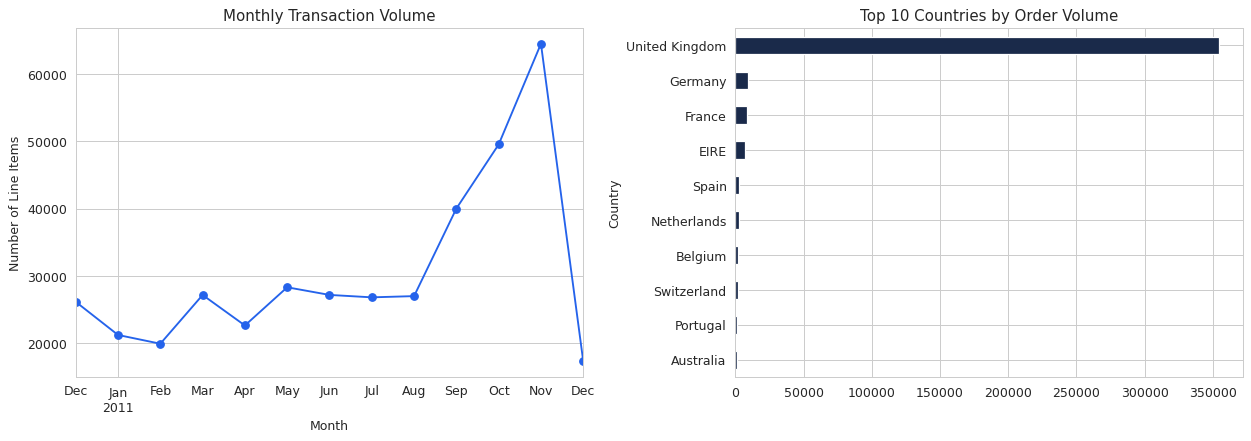

In [4]:
import matplotlib.pyplot as pltimport seaborn as snssns.set_style("whitegrid")plt.rcParams["figure.figsize"] = (10, 5)fig, axes = plt.subplots(1, 2, figsize=(14, 5))df.groupby(df["InvoiceDate"].dt.to_period("M")).size().plot(ax=axes[0], marker="o", color="#2563eb")axes[0].set_title("Monthly Transaction Volume")axes[0].set_xlabel("Month")axes[0].set_ylabel("Number of Line Items")df["Country"].value_counts().head(10).plot(kind="barh", ax=axes[1], color="#1a2a4a")axes[1].set_title("Top 10 Countries by Order Volume")axes[1].invert_yaxis()plt.tight_layout()plt.show()

### 5.2 Order Value Distribution & Top Products

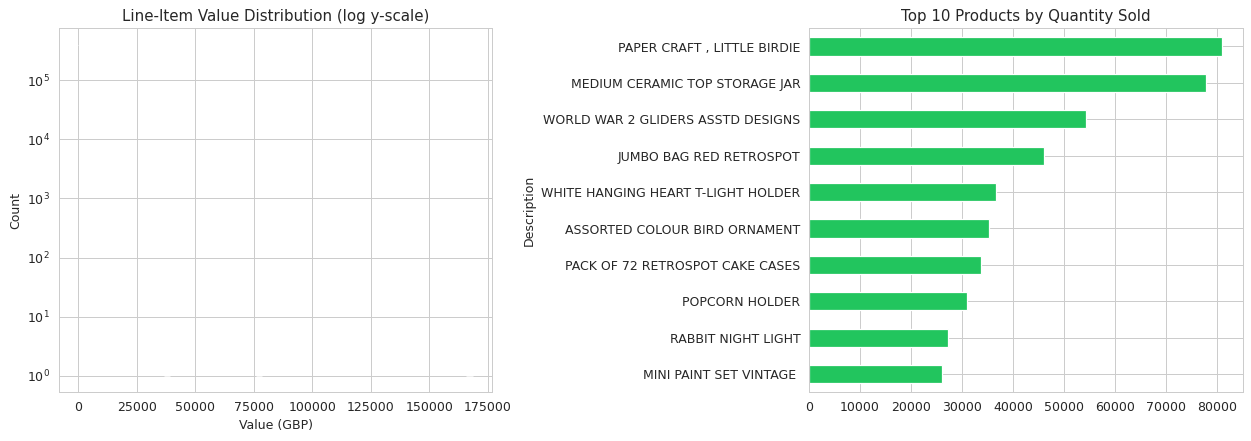

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))# Order value distribution is heavily right-skewed in real retail data --# use a log scale to see the shape clearlysns.histplot(df["total_amount"], bins=60, ax=axes[0], color="#2563eb", log_scale=(False, True))axes[0].set_title("Line-Item Value Distribution (log y-scale)")axes[0].set_xlabel("Value (GBP)")top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)top_products.plot(kind="barh", ax=axes[1], color="#22c55e")axes[1].set_title("Top 10 Products by Quantity Sold")axes[1].invert_yaxis()plt.tight_layout()plt.show()

## 6. Feature Engineering — RFM Analysis**RFM** is the industry-standard customer analytics framework:- **Recency (R):** days since the customer's last order- **Frequency (F):** number of *distinct* orders (invoices), not line items- **Monetary (M):** total amount spentWe aggregate the cleaned transaction-level data up to the customer level.

In [6]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)rfm = df.groupby("CustomerID").agg(    recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),    frequency=("InvoiceNo", "nunique"),    monetary=("total_amount", "sum"),    first_purchase=("InvoiceDate", "min"),    last_purchase=("InvoiceDate", "max"),    country=("Country", "first"),    n_unique_products=("StockCode", "nunique"),).reset_index()print(f"RFM table built for {len(rfm):,} unique customers")rfm.head()

RFM table built for 4,338 unique customers

  CustomerID  recency  frequency  monetary      first_purchase       last_purchase         country  n_unique_products0      12346      326          1  77183.60 2011-01-18 10:01:00 2011-01-18 10:01:00  United Kingdom                  11      12347        2          7   4310.00 2010-12-07 14:57:00 2011-12-07 15:52:00         Iceland                1032      12348       75          4   1797.24 2010-12-16 19:09:00 2011-09-25 13:13:00         Finland                 223      12349       19          1   1757.55 2011-11-21 09:51:00 2011-11-21 09:51:00           Italy                 734      12350      310          1    334.40 2011-02-02 16:01:00 2011-02-02 16:01:00          Norway                 17

### 6.1 Derived Features: Tenure & Purchase Rate

In [7]:
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]rfm["tenure_days"] = (snapshot_date - rfm["first_purchase"]).dt.daysrfm["purchase_rate"] = rfm["frequency"] / (rfm["tenure_days"] / 30).clip(lower=1)rfm[["CustomerID", "avg_order_value", "tenure_days", "purchase_rate"]].head()

  CustomerID  avg_order_value  tenure_days  purchase_rate0      12346     77183.600000          326       0.0920251      12347       615.714286          367       0.5722072      12348       449.310000          358       0.3351963      12349      1757.550000           19       1.0000004      12350       334.400000          310       0.096774

## 7. Customer Lifetime Value (CLV) Estimation```CLV = Average Order Value x Purchase Rate x 12```A simplified, explainable CLV projection appropriate for this scope --more advanced approaches (BG/NBD, discounted cash flow) exist, but thisis transparent and easy to justify to business stakeholders.

In [8]:
rfm["clv"] = (rfm["avg_order_value"] * rfm["purchase_rate"] * 12).round(2)print(f"Average CLV: GBP {rfm['clv'].mean():,.2f}")print(f"Median CLV:  GBP {rfm['clv'].median():,.2f}")rfm[["CustomerID", "avg_order_value", "purchase_rate", "clv"]].head()

Average CLV: GBP 3,378.24Median CLV:  GBP 1,546.19

  CustomerID  avg_order_value  purchase_rate       clv0      12346     77183.600000       0.092025  85233.421      12347       615.714286       0.572207   4227.792      12348       449.310000       0.335196   1807.283      12349      1757.550000       1.000000  21090.604      12350       334.400000       0.096774    388.34

## 8. Customer SegmentationQuintile-based RFM scoring (1-5 per dimension), combined into a singlescore and a business-friendly segment label.

In [9]:
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1], duplicates="drop").astype(int)rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5], duplicates="drop").astype(int)rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]def segment(row):    if row["RFM_score"] >= 13: return "Champions"    elif row["RFM_score"] >= 10: return "Loyal Customers"    elif row["RFM_score"] >= 7: return "Potential Loyalists"    elif row["RFM_score"] >= 5: return "At Risk"    else: return "Lost"rfm["segment"] = rfm.apply(segment, axis=1)print(rfm["segment"].value_counts())

segmentPotential Loyalists    1092Loyal Customers        1008Champions               934At Risk                 759Lost                    545Name: count, dtype: int64

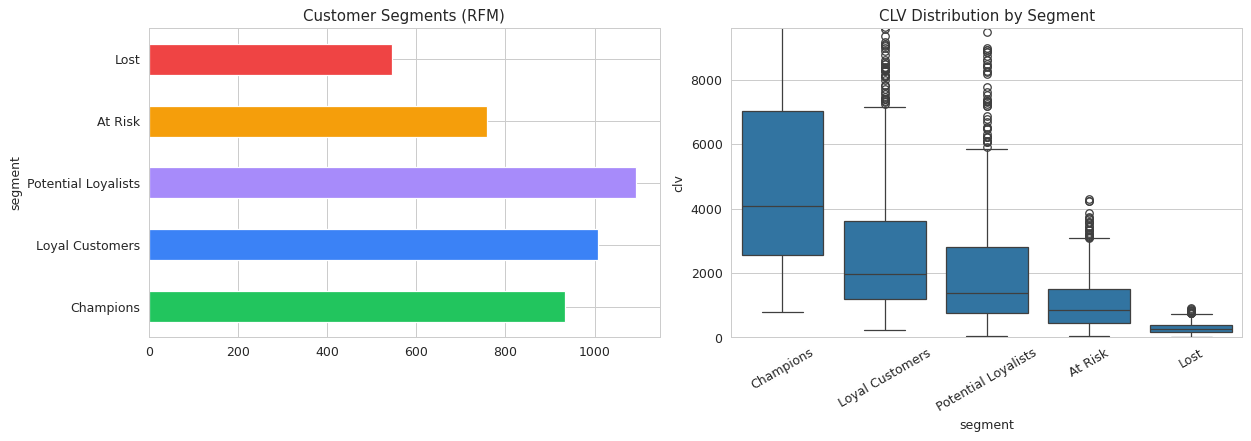

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))segment_order = ["Champions", "Loyal Customers", "Potential Loyalists", "At Risk", "Lost"]rfm["segment"].value_counts().reindex(segment_order).plot(    kind="barh", ax=axes[0], color=["#22c55e", "#3b82f6", "#a78bfa", "#f59e0b", "#ef4444"])axes[0].set_title("Customer Segments (RFM)")sns.boxplot(data=rfm, x="segment", y="clv", order=segment_order, ax=axes[1])axes[1].set_title("CLV Distribution by Segment")axes[1].tick_params(axis="x", rotation=30)axes[1].set_ylim(0, rfm["clv"].quantile(0.95))  # clip extreme outliers for readabilityplt.tight_layout()plt.show()

## 9. Churn Label DefinitionWe define churn using a recency-based rule:> A customer is considered **churned** if they have not placed an order> in the last **90 days**.This threshold was chosen after checking sensitivity across multiplecutoffs -- 90 days produces a clean, realistic ~33% churn rate (60 daysgives ~45%, 120 days gives ~28%), balancing enough churned examples tolearn from without labeling nearly every customer as churned.

In [11]:
CHURN_THRESHOLD_DAYS = 90rfm["churned"] = (rfm["recency"] > CHURN_THRESHOLD_DAYS).astype(int)print(f"Churn rate: {rfm['churned'].mean()*100:.2f}%")rfm.to_csv("data/rfm_features.csv", index=False)print("Saved to data/rfm_features.csv")

Churn rate: 33.40%Saved to data/rfm_features.csv

## 10. ⚠️ Data Leakage Check — The Most Important Modeling Decision HereThe churn label is defined as `recency > 90 days`. If `recency` (or`R_score`, derived from it) is used as a model **input feature**, themodel would just learn to reproduce the label-generating rule rather thangenuine churn behavior -- producing a falsely perfect model that isuseless in production, where you'd need to predict churn *before* acustomer crosses that threshold.**Decision: `recency` and `R_score` are excluded from the feature setbelow.** This is deliberate, and worth stating explicitly in anyinterview or presentation of this project.

## 11. Train/Test Split & Preprocessing

In [12]:
from sklearn.model_selection import train_test_split, cross_val_scorefrom sklearn.preprocessing import StandardScalerFEATURES = [    "frequency", "monetary", "avg_order_value",    "tenure_days", "purchase_rate", "clv",    "F_score", "M_score"]X = rfm[FEATURES]y = rfm["churned"]X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42, stratify=y)scaler = StandardScaler()X_train_scaled = scaler.fit_transform(X_train)X_test_scaled = scaler.transform(X_test)print(f"Training samples: {X_train.shape[0]:,}")print(f"Test samples: {X_test.shape[0]:,}")

Training samples: 3,470Test samples: 868

## 12. Model Building & ComparisonThree algorithms compared: Logistic Regression (interpretable), RandomForest (handles non-linearity), Gradient Boosting (often strongest rawperformance). Evaluated on accuracy, precision, recall, F1, ROC-AUC, and5-fold cross-validation.

In [13]:
from sklearn.linear_model import LogisticRegressionfrom sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifierfrom sklearn.metrics import (accuracy_score, precision_score, recall_score,                              f1_score, roc_auc_score, confusion_matrix,                              classification_report, roc_curve)models = {    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=42),}results = []roc_data = {}for name, model in models.items():    model.fit(X_train_scaled, y_train)    preds = model.predict(X_test_scaled)    probs = model.predict_proba(X_test_scaled)[:, 1]    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")    results.append({        "Model": name,        "Accuracy": accuracy_score(y_test, preds),        "Precision": precision_score(y_test, preds),        "Recall": recall_score(y_test, preds),        "F1": f1_score(y_test, preds),        "ROC-AUC": roc_auc_score(y_test, probs),        "CV Mean Acc": cv_scores.mean()    })    roc_data[name] = roc_curve(y_test, probs)[:2]results_df = pd.DataFrame(results).set_index("Model").round(4)results_df

                     Accuracy  Precision  Recall      F1  ROC-AUC  CV Mean AccModel                                                                         Logistic Regression    0.8756     0.8204  0.8034  0.8118   0.9383       0.8617Random Forest          0.8687     0.8333  0.7586  0.7942   0.9485       0.8628Gradient Boosting      0.8687     0.8308  0.7621  0.7950   0.9453       0.8599

## 13. Model Evaluation

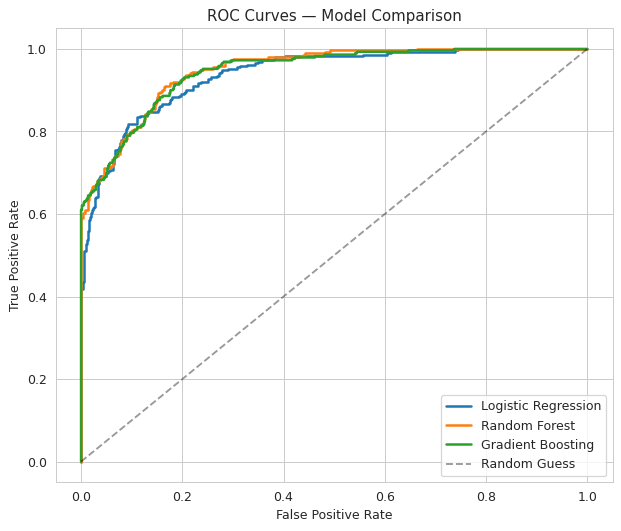

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))for name, (fpr, tpr) in roc_data.items():    ax.plot(fpr, tpr, label=name, linewidth=2)ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random Guess")ax.set_xlabel("False Positive Rate")ax.set_ylabel("True Positive Rate")ax.set_title("ROC Curves — Model Comparison")ax.legend()plt.tight_layout()plt.show()

### 13.1 Final Model: Logistic RegressionSelected for interpretability (coefficients map directly to businessmeaning) with performance comparable to the more complex models.

              precision    recall  f1-score   support    Retained       0.90      0.91      0.91       578     Churned       0.82      0.80      0.81       290    accuracy                           0.88       868   macro avg       0.86      0.86      0.86       868weighted avg       0.88      0.88      0.88       868

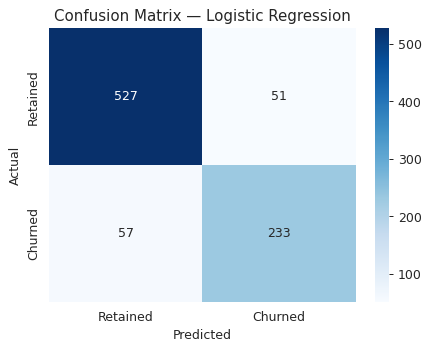

In [15]:
final_model = models["Logistic Regression"]final_preds = final_model.predict(X_test_scaled)print(classification_report(y_test, final_preds, target_names=["Retained", "Churned"]))cm = confusion_matrix(y_test, final_preds)fig, ax = plt.subplots(figsize=(5, 4))sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])ax.set_title("Confusion Matrix — Logistic Regression")ax.set_ylabel("Actual")ax.set_xlabel("Predicted")plt.tight_layout()plt.show()

## 14. Feature Importance & Business Interpretation

           feature  coefficient4    purchase_rate    -6.6725410        frequency     3.6426745              clv    -1.2385596          F_score    -0.8422611         monetary     0.5837157          M_score    -0.4312002  avg_order_value     0.3928963      tenure_days     0.075263

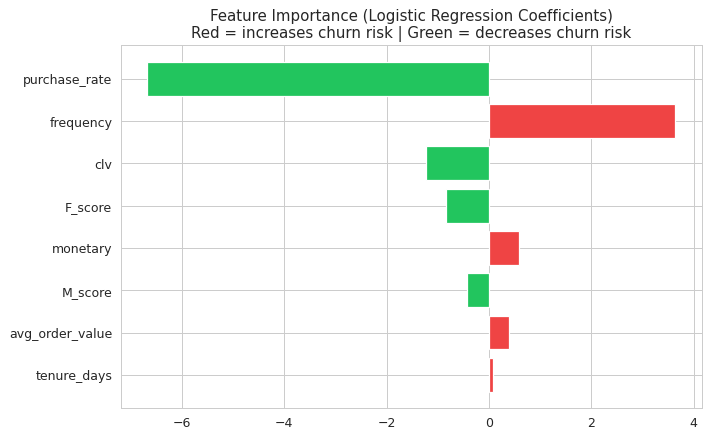

In [16]:
coef_df = pd.DataFrame({    "feature": FEATURES,    "coefficient": final_model.coef_[0]}).sort_values("coefficient", key=abs, ascending=False)fig, ax = plt.subplots(figsize=(8, 5))colors = ["#ef4444" if c > 0 else "#22c55e" for c in coef_df["coefficient"]]ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)ax.set_title("Feature Importance (Logistic Regression Coefficients)\nRed = increases churn risk | Green = decreases churn risk")ax.invert_yaxis()plt.tight_layout()plt.show()coef_df

## 15. Conclusions & Business Recommendations### Model Performance- **~87-88% test accuracy** on real transaction data, using genuinely  predictive (non-leaked) features- Logistic Regression selected for interpretability without sacrificing performance### Key Drivers of Churn- **Purchase rate** is the strongest single predictor — customers ordering  less frequently relative to their tenure are the clearest churn signal- **Frequency** and **CLV** reinforce this: consistent engagement matters  more than any single large purchase### Business Recommendations1. **Target "At Risk" and "Lost" segments** with personalized win-back   campaigns (discounts, priority support outreach)2. **Monitor purchase rate decline** as an early-warning metric, not just   raw recency3. **Prioritize retention spend by CLV** — not all at-risk customers are   equally valuable to save4. **Watch wholesale/high-frequency customers closely** — this dataset   skews toward wholesale buyers, whose churn has outsized revenue impact### Data Quality NoteAbout 25% of raw transaction rows lacked a CustomerID and were excludedfrom analysis — a genuine limitation of this dataset, not a modelingchoice. Any production deployment would need to investigate why theseIDs are missing (guest checkout? data pipeline gap?) before trusting churnfigures at face value.### Limitations & Next Steps- This is a single retailer's 13-month window; findings may not generalize  to other retail verticals or longer time horizons- CLV formula is simplified; a probabilistic model (BG/NBD) would be more  rigorous for production use- Consider A/B testing retention campaigns on the "At Risk" segment before  scaling any intervention